# Primary dataset baseline modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load csv files and check shapes to confirm they were saved correctly
train_df = pd.read_csv('data/IEEE-CIS/train_noNaN.csv')
val_df   = pd.read_csv('data/IEEE-CIS/val_noNaN.csv')
test_df  = pd.read_csv('data/IEEE-CIS/test_noNaN.csv')

print("Train set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Test set shape:", test_df.shape)

Train set shape: (413378, 481)
Validation set shape: (88581, 481)
Test set shape: (88581, 481)


## 1. LightGBM with class weighting

In [3]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score

In [4]:
# class weight to handle imbalance
neg, pos = (train_df['isFraud'] == 0).sum(), (train_df['isFraud'] == 1).sum()
scale = neg / pos  # ~27 given 3.5% fraud rate

feature_cols = [c for c in train_df.columns 
                if c not in ['isFraud', 'TransactionID', 'TransactionDT']
                and train_df[c].dtype not in ['object', 'str']
                and str(train_df[c].dtype) not in ['object', 'str', 'string']]

model = lgb.LGBMClassifier(
    n_estimators=500,
    scale_pos_weight=scale,  # handles imbalance
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(
    train_df[feature_cols], train_df['isFraud'],
    eval_set=[(val_df[feature_cols], val_df['isFraud'])],
)

val_preds = model.predict_proba(val_df[feature_cols])[:, 1]
print('ROC AUC:', roc_auc_score(val_df['isFraud'], val_preds))
print('AUPRC:',   average_precision_score(val_df['isFraud'], val_preds))

[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.868349 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
ROC AUC: 0.8771880367475091
AUPRC: 0.5301385217227261


In [5]:
print(f"Number of features: {len(feature_cols)}")
print(train_df[feature_cols].dtypes.value_counts())

Number of features: 447
float64    390
int64       57
Name: count, dtype: int64


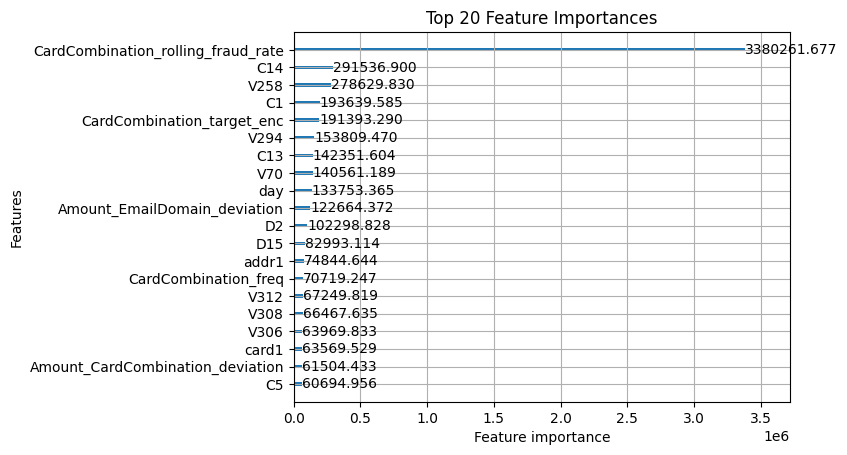

In [7]:
# check feature importance of model
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Top 20 Feature Importances")
plt.show()

## 2. Improve model with hyperparameter tuning

In [8]:
import optuna

In [12]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 800),
        'scale_pos_weight': scale,
        'random_state': 42,
        'n_jobs': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    model_2 = lgb.LGBMClassifier(**params)
    model_2.fit(
        train_df[feature_cols], train_df['isFraud'],
        callbacks=[lgb.log_evaluation(-1)]  # silent, no early stopping
    )
    
    val_preds = model_2.predict_proba(val_df[feature_cols])[:, 1]
    return average_precision_score(val_df['isFraud'], val_preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-04-16 18:25:48,009] A new study created in memory with name: no-name-b3990493-dbcb-49bc-91d3-df980b829267
  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.555344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

Best trial: 0. Best value: 0.508751:   2%|▏         | 1/50 [00:35<29:06, 35.64s/it]

[I 2026-04-16 18:26:23,649] Trial 0 finished with value: 0.5087509687816549 and parameters: {'n_estimators': 637, 'learning_rate': 0.03586172168774648, 'num_leaves': 39, 'max_depth': 6, 'min_child_samples': 111, 'subsample': 0.5644210301418456, 'colsample_bytree': 0.8012263444837038, 'reg_alpha': 0.08672614970674647, 'reg_lambda': 2.0766586571077335e-05}. Best is trial 0 with value: 0.5087509687816549.
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.662325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

Best trial: 1. Best value: 0.515866:   4%|▍         | 2/50 [01:59<51:11, 63.99s/it]

...

[I 2026-04-16 19:12:00,265] Trial 47 finished with value: 0.5382073669980415 and parameters: {'n_estimators': 746, 'learning_rate': 0.08242006246551674, 'num_leaves': 215, 'max_depth': 6, 'min_child_samples': 178, 'subsample': 0.6988697599340139, 'colsample_bytree': 0.7772074531933262, 'reg_alpha': 0.009211628914556272, 'reg_lambda': 1.2283251155632433e-07}. Best is trial 34 with value: 0.5926197865792178.
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.560158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

Best trial: 34. Best value: 0.59262:  98%|█████████▊| 49/50 [47:29<01:03, 63.18s/it]

[I 2026-04-16 19:13:17,270] Trial 48 finished with value: 0.5917236615277639 and parameters: {'n_estimators': 704, 'learning_rate': 0.08770226353544201, 'num_leaves': 207, 'max_depth': 11, 'min_child_samples': 201, 'subsample': 0.7791202376504978, 'colsample_bytree': 0.7974982095576506, 'reg_alpha': 0.00025152871659923367, 'reg_lambda': 2.984612674020103e-07}. Best is trial 34 with value: 0.5926197865792178.
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.542899 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

Best trial: 34. Best value: 0.59262: 100%|██████████| 50/50 [48:46<00:00, 58.52s/it]

[I 2026-04-16 19:14:34,156] Trial 49 finished with value: 0.5739280192900169 and parameters: {'n_estimators': 704, 'learning_rate': 0.04916846349265423, 'num_leaves': 254, 'max_depth': 11, 'min_child_samples': 191, 'subsample': 0.7792925852357915, 'colsample_bytree': 0.8008960218310591, 'reg_alpha': 0.00018769016018774478, 'reg_lambda': 7.863227278804917e-08}. Best is trial 34 with value: 0.5926197865792178.


In [13]:
print('Best AUPRC:', study.best_value)
print('Best params:', study.best_params)

# retrain with best params and evaluate
best_model = lgb.LGBMClassifier(**study.best_params, scale_pos_weight=scale, random_state=42, n_jobs=-1)
best_model.fit(train_df[feature_cols], train_df['isFraud'],
               callbacks=[lgb.log_evaluation(-1)])

val_preds = best_model.predict_proba(val_df[feature_cols])[:, 1]
print('Best ROC AUC:', roc_auc_score(val_df['isFraud'], val_preds))
print('Best AUPRC:',  average_precision_score(val_df['isFraud'], val_preds))

Best AUPRC: 0.5926197865792178
Best params: {'n_estimators': 729, 'learning_rate': 0.08217972817474942, 'num_leaves': 230, 'max_depth': 12, 'min_child_samples': 233, 'subsample': 0.6384000874685906, 'colsample_bytree': 0.7773815436646605, 'reg_alpha': 4.243778357405213e-08, 'reg_lambda': 0.002872022743031918}
[LightGBM] [Info] Number of positive: 14538, number of negative: 398840
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.842673 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36453
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 445
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311794
[LightGBM] [Info] Start training from score -3.311794
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi